## Test the rearangemenet of xs 

In [11]:
import csv
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from multiprocessing import Pool
import sys
sys.path.append('/Users/vicentiastroe/Documents/Thesis/FrodoKEM/InitialVersion/aes_sim_test')
from ANALYSIS_vista_utils_ARM import *
import shutil
import os
from ANALYSIS_plots_utils import *
from reset_folder_notebook import *

In [12]:
def plot_first_traces(trace_items, title, max_traces, save_path=None, no_instructions=None):
    plt.close("all")
    plt.figure(figsize=(30, 6))
    if no_instructions is not None:
        plt.xlim(0, no_instructions)

    for k, item in enumerate(trace_items[:max_traces]):
        if len(item) == 3:
            run_index, xs_id, trace = item
            fault_label = ""
        elif len(item) == 4:
            run_index, xs_id, fault_index, trace = item
            fault_label = f", fault={fault_index}"
        else:
            raise ValueError(f"Unexpected trace item format with {len(item)} values: {item}")

        plt.plot(trace, alpha=0.7, label=f"{k}: run={run_index}, xs={xs_id}{fault_label}")

    plt.title(title)
    plt.xlabel("Instruction index")
    plt.ylabel("Leakage value")
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)

    plt.show()

In [13]:
def HW(a):
    return a.count('1')

def HD(a,b):
#     print(type(sum(c1 != c2 for c1, c2 in zip(a, b)) ))
    return sum(c1 != c2 for c1, c2 in zip(a, b)) 

def hex_to_bin32(x):
    return bin(int(x, 0))[2:].rjust(32, '0')

def create_HD_trace(filename, cols):
    df = pd.read_csv(filename)
    df.fillna('0x0', inplace=True)

    reg_bin = []
    for col in cols:
        reg_bin.append(df[col].apply(hex_to_bin32).tolist())

    number_instructions = len(reg_bin[0])
    hd_ref = np.zeros((number_instructions - 1, len(cols)))

    for col in range(len(cols)):
        for i in range(number_instructions - 1):
            hd_ref[i, col] = HD(reg_bin[col][i], reg_bin[col][i + 1])

    return np.sum(hd_ref, axis=1)


def create_HW_trace(filename,cols):
      """
      reads an execution trace in csv format 
      returns 
      - the hamming weight of  the content of all registers for each instruction
      - the total number of instructions

      """
      df = pd.read_csv(filename)
      df.fillna('0x0', inplace=True)
      #cols = ['zero', 'ra', 'sp', 'gp', 'tp', 't0', 't1','t2', 's0', 's1', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 's2',
      #  's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 't3', 't4','t5', 't6']
     #cols = ['t1', 's0', 'a0', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 't3']
      # convert hex register values to binary and decimal values
      reg_bin=[]
      for col in cols:
          reg_bin.append(df[col].apply(hex_to_bin32).tolist())

      number_instructions = len(reg_bin[0])# number of instructions
      hw_ref = np.zeros((number_instructions ,len(cols)))
      for col in range(len(cols)):
        for i in range(number_instructions):
            hw_ref[i,col] = HW(reg_bin[col][i])
      return  np.sum(hw_ref,axis=1)




In [14]:
def create_npy_file_truncated(name_npy_file, folder, leakage_model, no_printed_traces, cols, debug_plot_dir=None):
    def resolve_trace_folder(folder):
        folder = Path(folder)
        if folder.exists():
            return folder

        repo_relative = Path.cwd() / folder.name
        if repo_relative.exists():
            return repo_relative

        raise FileNotFoundError(f"Trace folder does not exist: {folder}")

    def parse_trace_name(path):
        match = re.match(r"trace_(\d+)_(\d+)_(\d+)\.csv$", path.name)
        if match is None:
            return None

        run_index = int(match.group(1))
        xs_id = int(match.group(2))
        fault_index = int(match.group(3))
        return run_index, xs_id, fault_index

    print("Creating simulation traces model....", leakage_model)

    folder = resolve_trace_folder(folder)
    files_raw = []
    no_instructions = 500

    for file in Path(folder).glob("trace_*_*_*.csv"):
        parsed = parse_trace_name(file)
        if parsed is None:
            continue

        run_index, xs_id, fault_index = parsed
        files_raw.append((run_index, xs_id, fault_index, file))

    print(f"Found {len(files_raw)} truncated trace files in {folder}")
    if not files_raw:
        raise FileNotFoundError(f"No truncated traces matching trace_<run>_<xs>_<fault>.csv found in {folder}")

    # Before rearranging: keep traces grouped by run and fault, so the first block shows different xs values.
    files_before = sorted(files_raw, key=lambda x: (x[0], x[2], x[1]))
    traces_before = []

    for count, (run_index, xs_id, fault_index, file) in enumerate(files_before):
        if count % 100 == 0:
            print(f"Trace {count} has been converted")

        if leakage_model == "HW":
            trace = create_HW_trace(file, cols)
        elif leakage_model == "HD":
            trace = create_HD_trace(file, cols)
        else:
            raise ValueError("leakage_model must be 'HW' or 'HD'")

        traces_before.append((run_index, xs_id, fault_index, trace))

    traces_after = sorted(traces_before, key=lambda x: (x[1], x[0], x[2]))

    if debug_plot_dir is not None:
        os.makedirs(debug_plot_dir, exist_ok=True)
        plot_first_traces(traces_before, title=f"{leakage_model}: first 8 traces BEFORE rearranging", max_traces=no_printed_traces, save_path=os.path.join(debug_plot_dir, f"{leakage_model}_before_rearranging.png"), no_instructions=no_instructions)
        plot_first_traces(traces_after, title=f"{leakage_model}: first 8 traces AFTER rearranging by xs", max_traces=no_printed_traces, save_path=os.path.join(debug_plot_dir, f"{leakage_model}_after_rearranging.png"), no_instructions=no_instructions)

    traces_by_xs = {xs_id: [] for xs_id in range(8)}

    for run_index, xs_id, fault_index, trace in traces_after:
        traces_by_xs[xs_id].append(trace)

    missing_xs = [xs_id for xs_id, traces in traces_by_xs.items() if not traces]
    if missing_xs:
        raise ValueError(f"No traces found for xs_id values: {missing_xs}")

    for xs_id in range(8):
        min_len = min(len(t) for t in traces_by_xs[xs_id])
        vectors_array = np.array([t[:min_len] for t in traces_by_xs[xs_id]])

        npy_name = f"{name_npy_file}_xs{xs_id}.npy"
        np.save(npy_name, vectors_array)

        print(f"Saved {npy_name}, shape = {vectors_array.shape}")

    print("Finished creating truncated npy files")

    return traces_before, traces_after, traces_by_xs

Creating simulation traces model.... HW
Found 103040 truncated trace files in ../output_decapsulation_truncated_TRIM
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted
Trace 700 has been converted
Trace 800 has been converted
Trace 900 has been converted
Trace 1000 has been converted
Trace 1100 has been converted
Trace 1200 has been converted
Trace 1300 has been converted
Trace 1400 has been converted
Trace 1500 has been converted
Trace 1600 has been converted
Trace 1700 has been converted
Trace 1800 has been converted
Trace 1900 has been converted
Trace 2000 has been converted
Trace 2100 has been converted
Trace 2200 has been converted
Trace 2300 has been converted
Trace 2400 has been converted
Trace 2500 has been converted
Trace 2600 has been converted
Trace 2700 has been converted
Trace 2800 has been converted
Trace 2900 has been conve

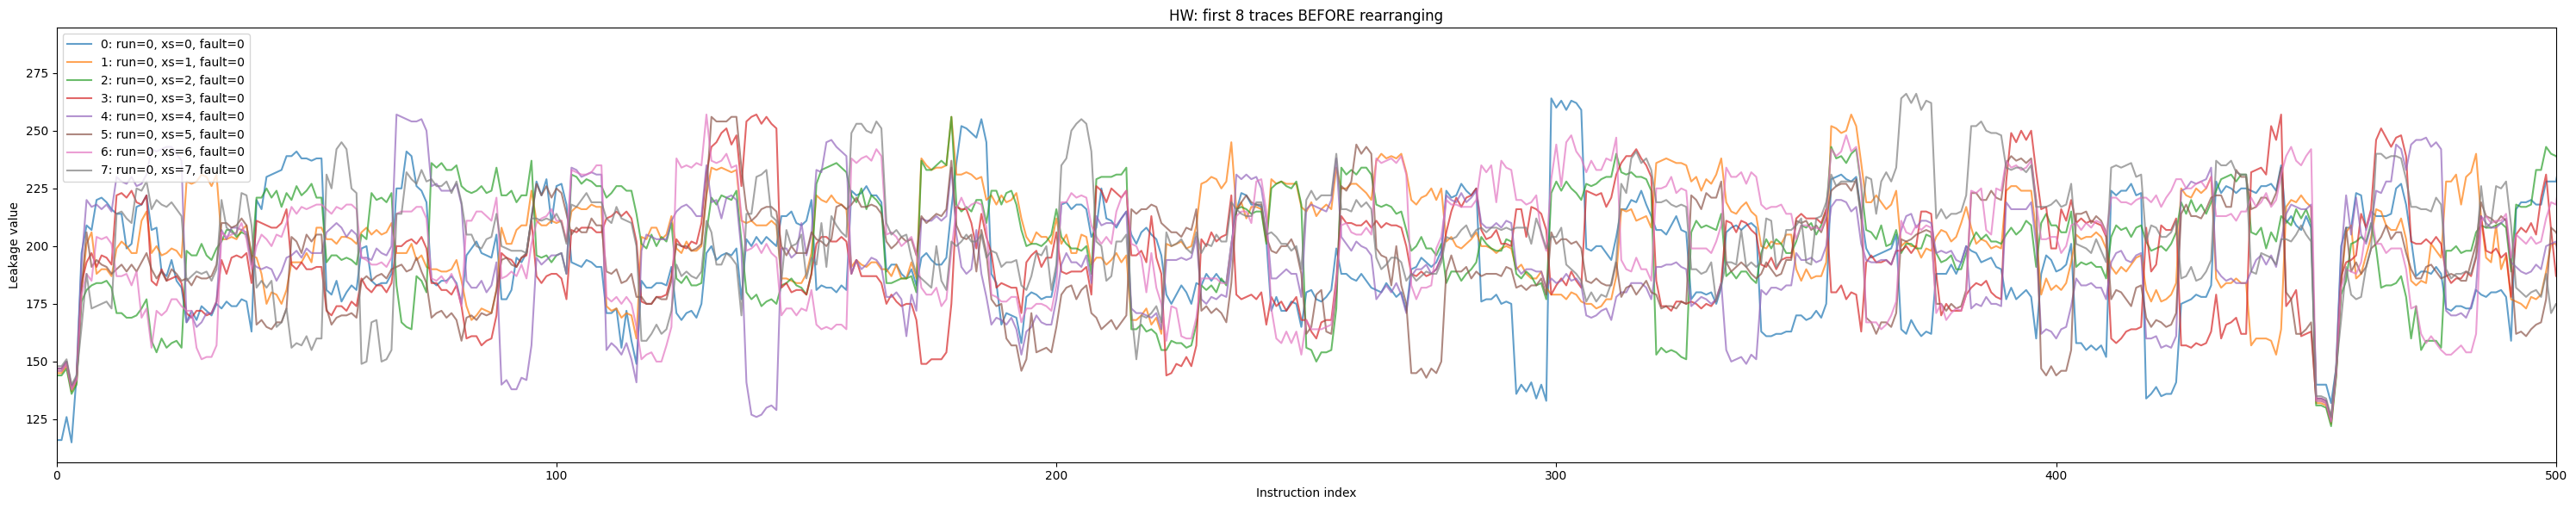

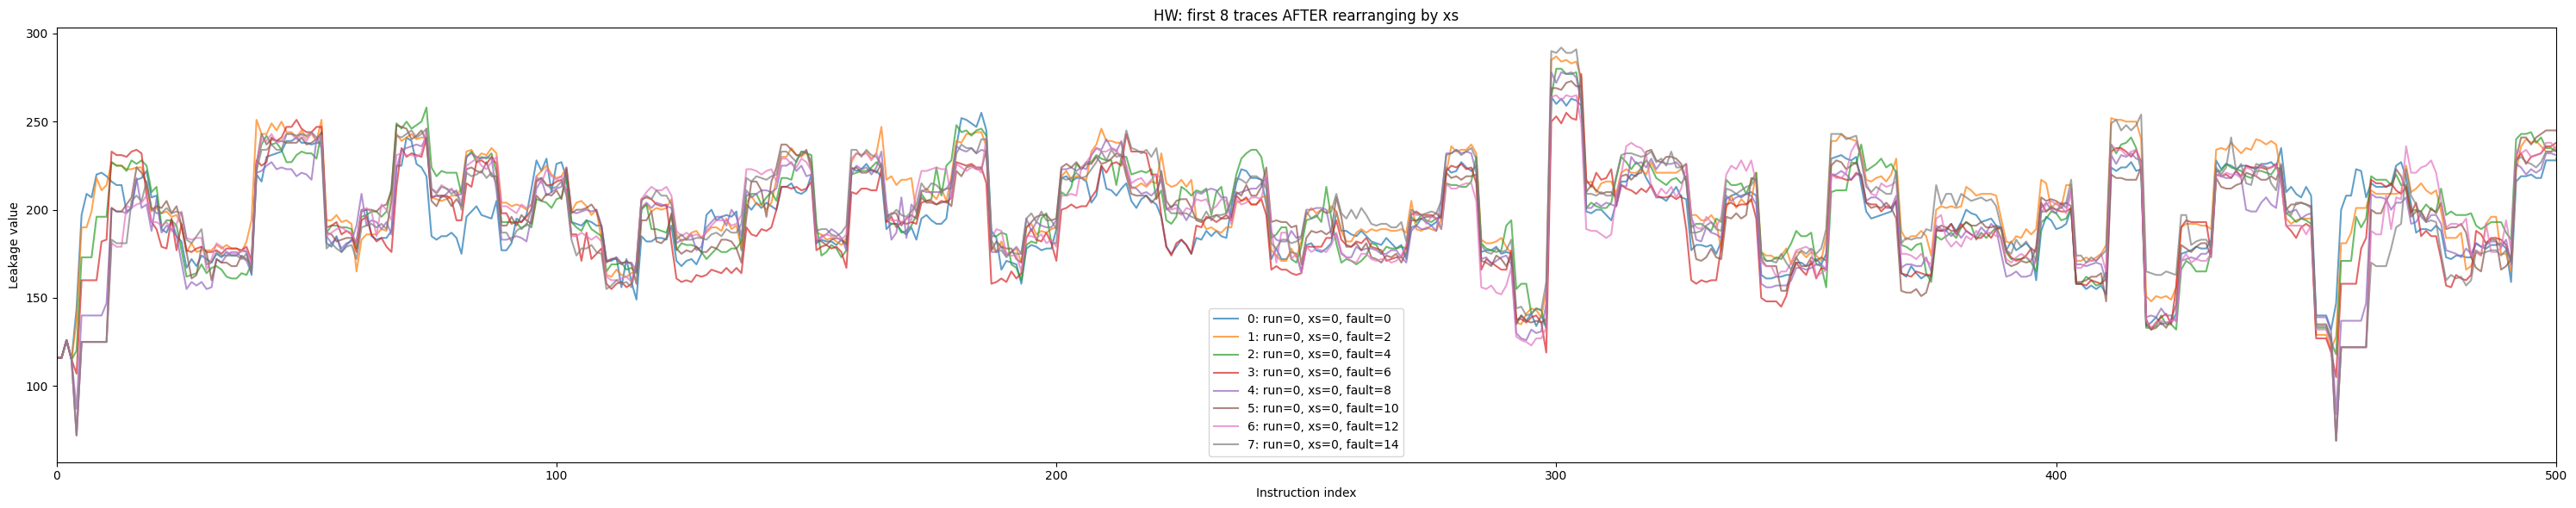

Saved Results_truncated_test/HW_SUBTRACE_xs0.npy, shape = (12880, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs1.npy, shape = (12880, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs2.npy, shape = (12880, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs3.npy, shape = (12880, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs4.npy, shape = (12880, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs5.npy, shape = (12880, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs6.npy, shape = (12880, 3616)
Saved Results_truncated_test/HW_SUBTRACE_xs7.npy, shape = (12880, 3616)
Finished creating truncated npy files
Creating simulation traces model.... HD
Found 103040 truncated trace files in ../output_decapsulation_truncated_TRIM
Trace 0 has been converted
Trace 100 has been converted
Trace 200 has been converted
Trace 300 has been converted
Trace 400 has been converted
Trace 500 has been converted
Trace 600 has been converted
Trace 700 has been converted
Trace 800 has been converted
Trace 900 

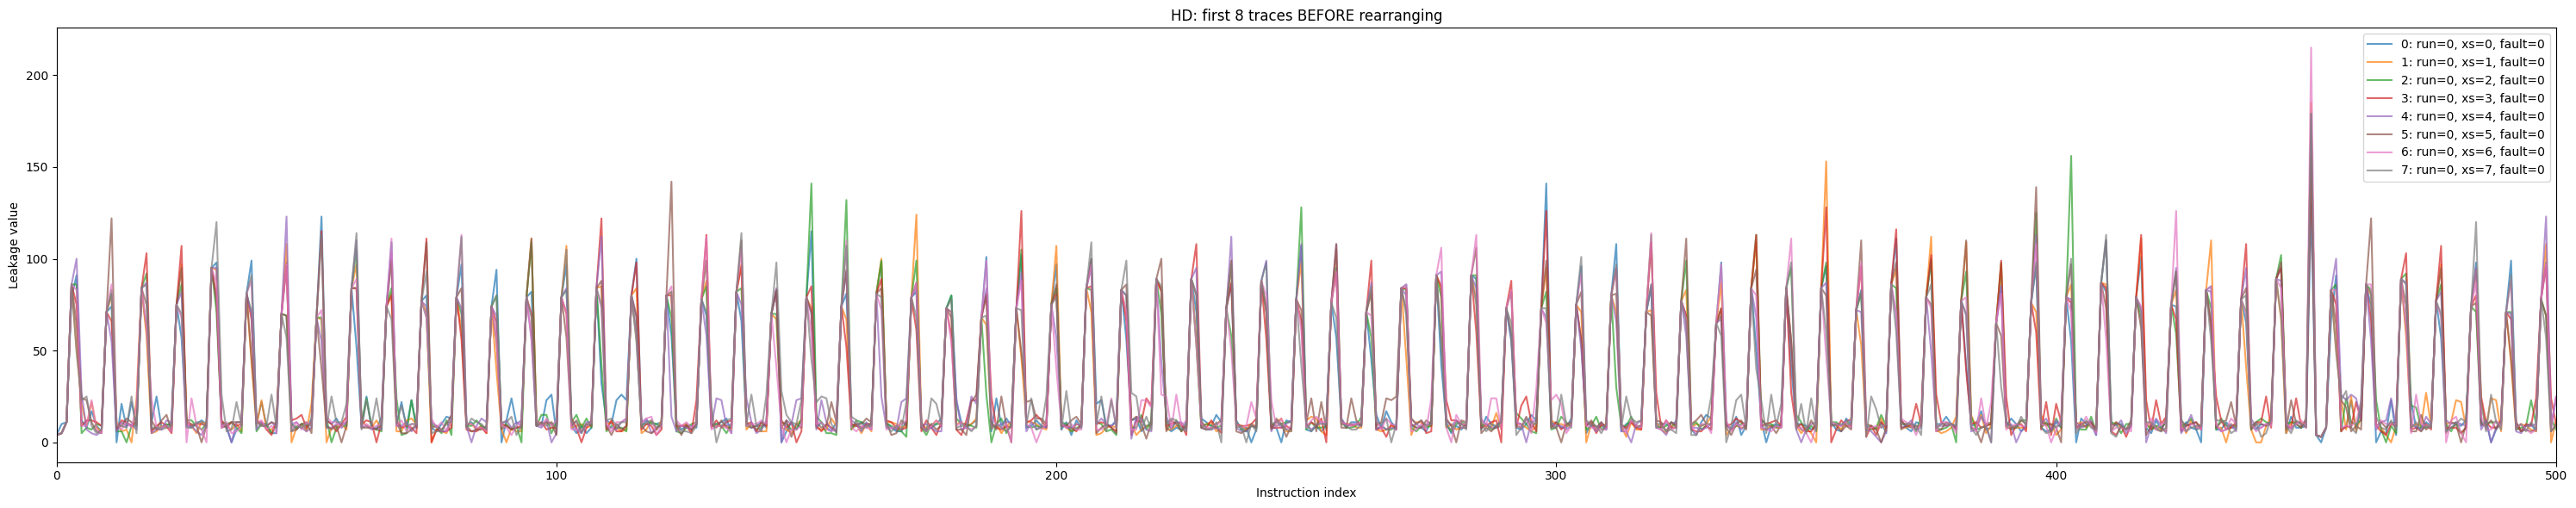

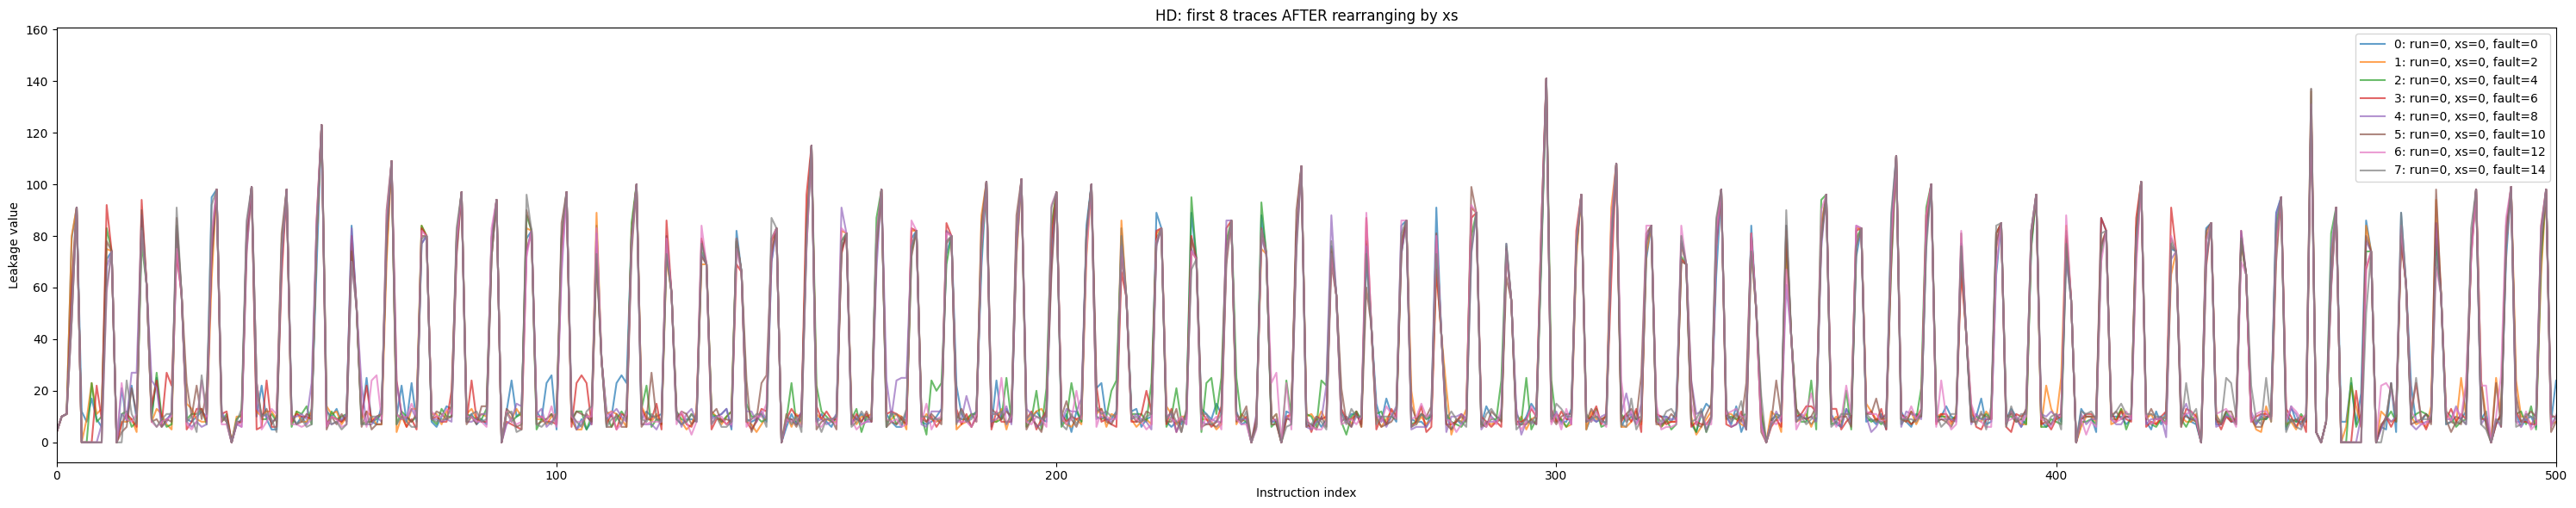

Saved Results_truncated_test/HD_SUBTRACE_xs0.npy, shape = (12880, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs1.npy, shape = (12880, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs2.npy, shape = (12880, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs3.npy, shape = (12880, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs4.npy, shape = (12880, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs5.npy, shape = (12880, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs6.npy, shape = (12880, 3615)
Saved Results_truncated_test/HD_SUBTRACE_xs7.npy, shape = (12880, 3615)
Finished creating truncated npy files


In [15]:
os.makedirs("Results_truncated_test", exist_ok=True)
result_dir_truncated = "Results_truncated_test"
reset_folder(result_dir_truncated)

folder = "../output_decapsulation_truncated_TRIM"
selected_registers= ['r0','r1','r2','r3','r4','r5','r6','r7','r8','r9','r10','r11','r12','sp','lr']

filename_hw = f"{result_dir_truncated}/HW_SUBTRACE"
no_printed_traces = 8
hw_before, hw_after, hw_by_xs = create_npy_file_truncated(
    filename_hw,
    folder,
    "HW",
    no_printed_traces,
    selected_registers,
    debug_plot_dir=result_dir_truncated
)

filename_hd = f"{result_dir_truncated}/HD_SUBTRACE"

hd_before, hd_after, hd_by_xs = create_npy_file_truncated(
    filename_hd,
    folder,
    "HD",
    no_printed_traces,
    selected_registers,
    debug_plot_dir=result_dir_truncated
)